In [143]:
import pandas_ta as pta
import numpy as np
import pandas as pd
import mplfinance as mpf
from tabulate import tabulate

from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Signals import Signals
from ggTrader.Backtest import Backtest
import matplotlib.pyplot as plt
import matplotlib.ticker as tck  # Import the ticker module
import seaborn as sns



In [144]:

top20_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    "TON",  # 20 Toncoin
    "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    "MNT",  # 23 Mantle
    "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

In [145]:
# Ticker

symbols = ["ZEC"]
interval = "4h"

# Time Range

end = pd.to_datetime("2025-09-30").tz_localize('UTC')
start = end - pd.Timedelta(days=30 * 6)
# start = pd.to_datetime("2023-01-01").tz_localize('UTC')
# Indicator Params
sar_acceleration = 0.02
sar_maximum = 0.2
atr_multiplier = 2.0  #atr multiplier for chandelier exit
adx_threshold = 10  #trend strength
adx_length = 14
ce_high_length = 22  # look back length
ce_low_length = 2

# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# portfolio
start_equity = 1000

#
k = KrakenHistoricalData()
s = Signals(

    atr_multiplier=atr_multiplier,
    adx_threshold=adx_threshold,
    adx_length=adx_length,
    ce_high_length=ce_high_length,
    ce_low_length=ce_low_length)
k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)
# df_multi = k.get_ohlcv_df(symbols, interval=interval)

print(df_multi.head())

# remove multi-index
print(start)
print(end)

df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]

print(f"\nMultiIndex Removed")
print(df.info())
print(df.head())
print(df.tail())

df_bench_mark = pd.DataFrame()
df_bench_mark['close'] = df['close'].copy()
df_bench_mark['equity'] = start_equity * df_bench_mark['close'] / (df_bench_mark['close'].iloc[0])
print(df_bench_mark.tail(10))

                                 ZEC                                   \
                                open       high        low      close   
2023-01-01 00:00:00+00:00  37.299999  37.299999  37.220001  37.250000   
2023-01-01 04:00:00+00:00  37.110001  37.380001  36.799999  36.910000   
2023-01-01 08:00:00+00:00  36.799999  36.869999  36.619999  36.630001   
2023-01-01 12:00:00+00:00  36.540001  36.849998  36.540001  36.849998   
2023-01-01 16:00:00+00:00  36.799999  37.049999  36.799999  37.049999   

                                                           
                                 volume trades base quote  
2023-01-01 00:00:00+00:00  6.306351e+04     16  ZEC   USD  
2023-01-01 04:00:00+00:00  1.561021e+06     73  ZEC   USD  
2023-01-01 08:00:00+00:00  1.358511e+05     37  ZEC   USD  
2023-01-01 12:00:00+00:00  2.191040e+04     10  ZEC   USD  
2023-01-01 16:00:00+00:00  3.371517e+04      7  ZEC   USD  
2025-04-03 00:00:00+00:00
2025-09-30 00:00:00+00:00

MultiIndex Remo

In [146]:
# Calculate indicators
signals = s.calc_signals(df.copy())

print(f"\nSignals:")
print(signals.info())
print(signals.head())
print(signals.tail())




Signals:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1081 entries, 2025-04-03 00:00:00+00:00 to 2025-09-30 00:00:00+00:00
Freq: 4h
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sar             504 non-null    float64
 1   sar_s           1081 non-null   bool   
 2   adx             1068 non-null   float64
 3   adx_d           1066 non-null   float64
 4   adx_dmp         1068 non-null   float64
 5   adx_dmn         1068 non-null   float64
 6   adx_s           1081 non-null   bool   
 7   adx_bullish     1081 non-null   bool   
 8   entry_signal    1081 non-null   bool   
 9   open            1081 non-null   float32
 10  high            1081 non-null   float32
 11  low             1081 non-null   float32
 12  close           1081 non-null   float32
 13  volume          1081 non-null   float64
 14  trades          1081 non-null   Int64  
 15  base            1081 non-null   object 
 16  quote      

In [147]:
# Backtest
bt = Backtest(signals,
              interval=interval,
              transaction_fee=transaction_fee,
              start_equity=start_equity)
stats, profit_df = bt.run()

print(f"\nBacktest Stats:")
print(tabulate(stats.items(), tablefmt='github'))



Backtest Stats:
|------------------|------------|
| trading_days     |  180       |
| total_profit     | 3786.45    |
| total_profit_pct |  378.645   |
| sharpe           |    5.94149 |
| sortino          |    7.6199  |
| wins             |   16       |
| losses           |    5       |
| win_rate         |   76.1905  |


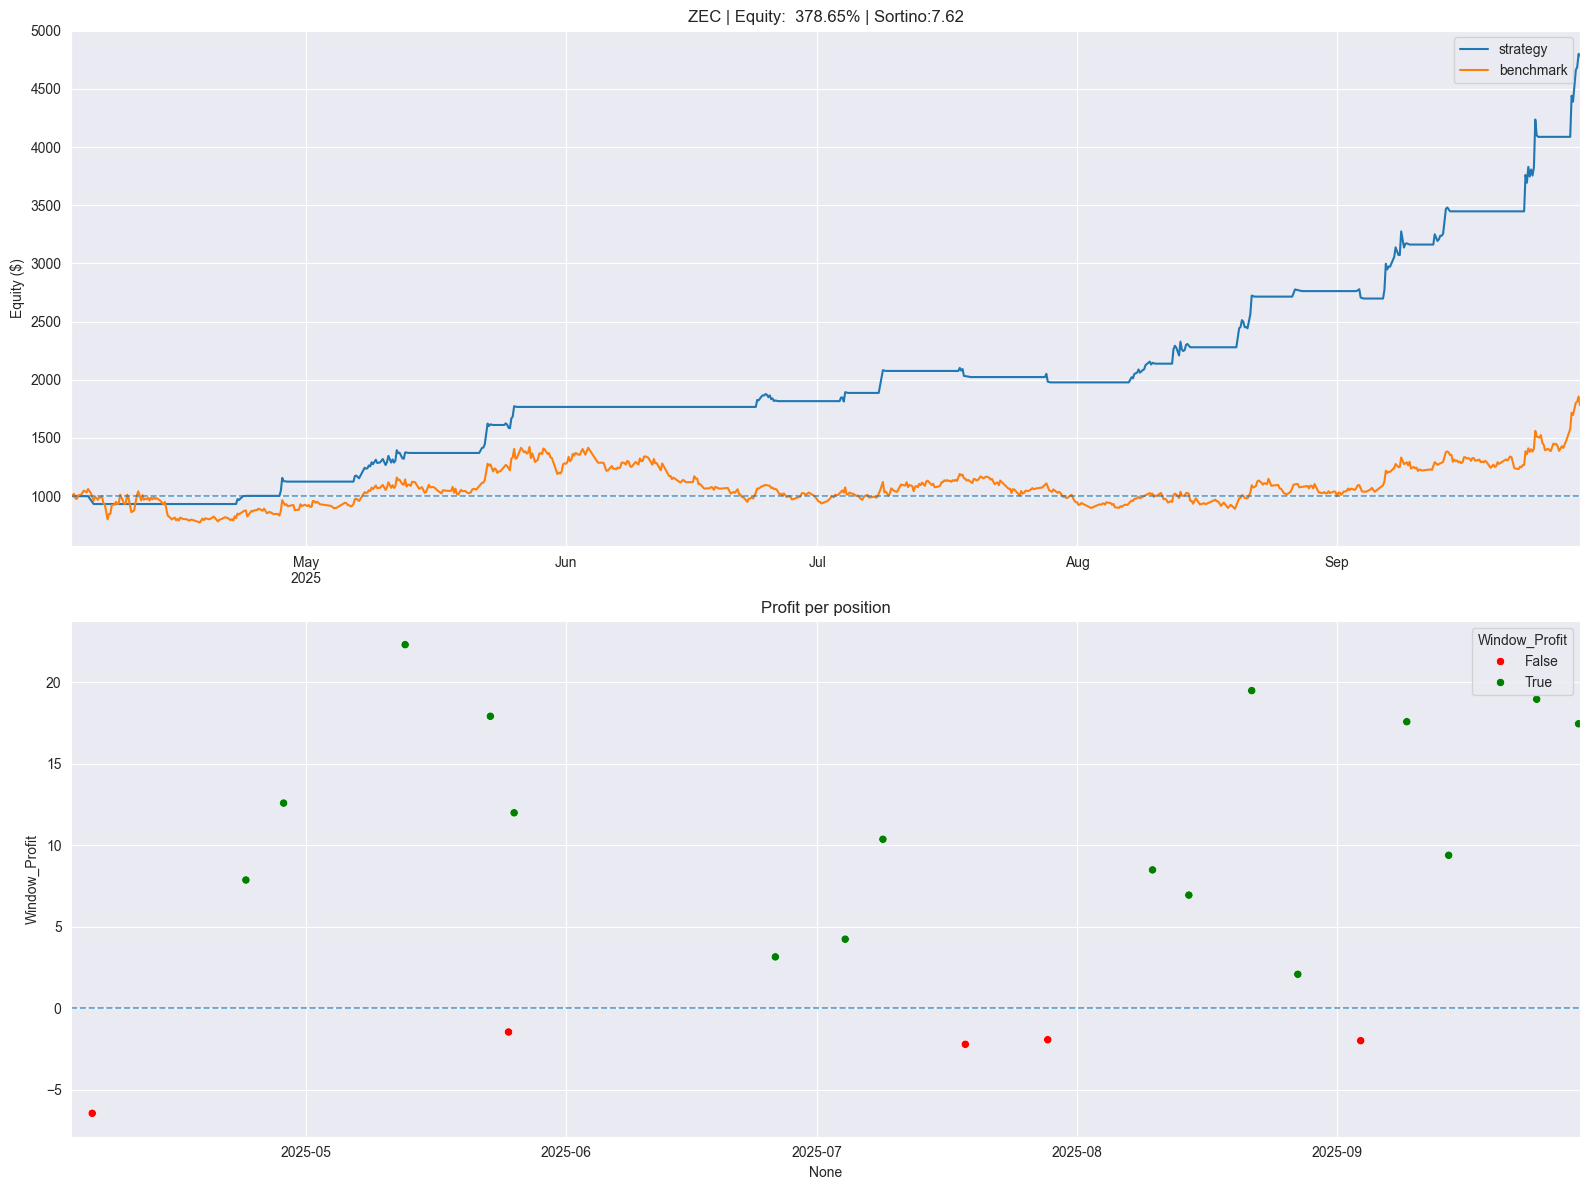

In [148]:
# plots
win_profit = profit_df['Window_Profit'] * 100
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
profit_df['Equity'].plot(ax=axes[0],
                         title=f'{symbols[0]} | Equity:  {stats["total_profit_pct"]:.2f}% | Sortino:{stats['sortino']:.2f}',
                         label='strategy')
df_bench_mark['equity'].plot(ax=axes[0], label='benchmark', secondary_y=False)
axes[0].set_ylabel('Equity ($)')
axes[0].legend()
axes[0].set_xlim(start, end)
# axes[0].set_yscale('log')
axes[0].axhline(start_equity, linestyle='--', linewidth=1.2, alpha=0.7)
sns.scatterplot(x=profit_df.index, y=win_profit, ax=axes[1], hue=win_profit > 0, palette={True: 'green', False: 'red'})
axes[1].set_title('Profit per position')
axes[1].axhline(0.0, linestyle='--', linewidth=1.2, alpha=0.7)
axes[1].set_xlim(start, end)
plt.tight_layout()
plt.show()

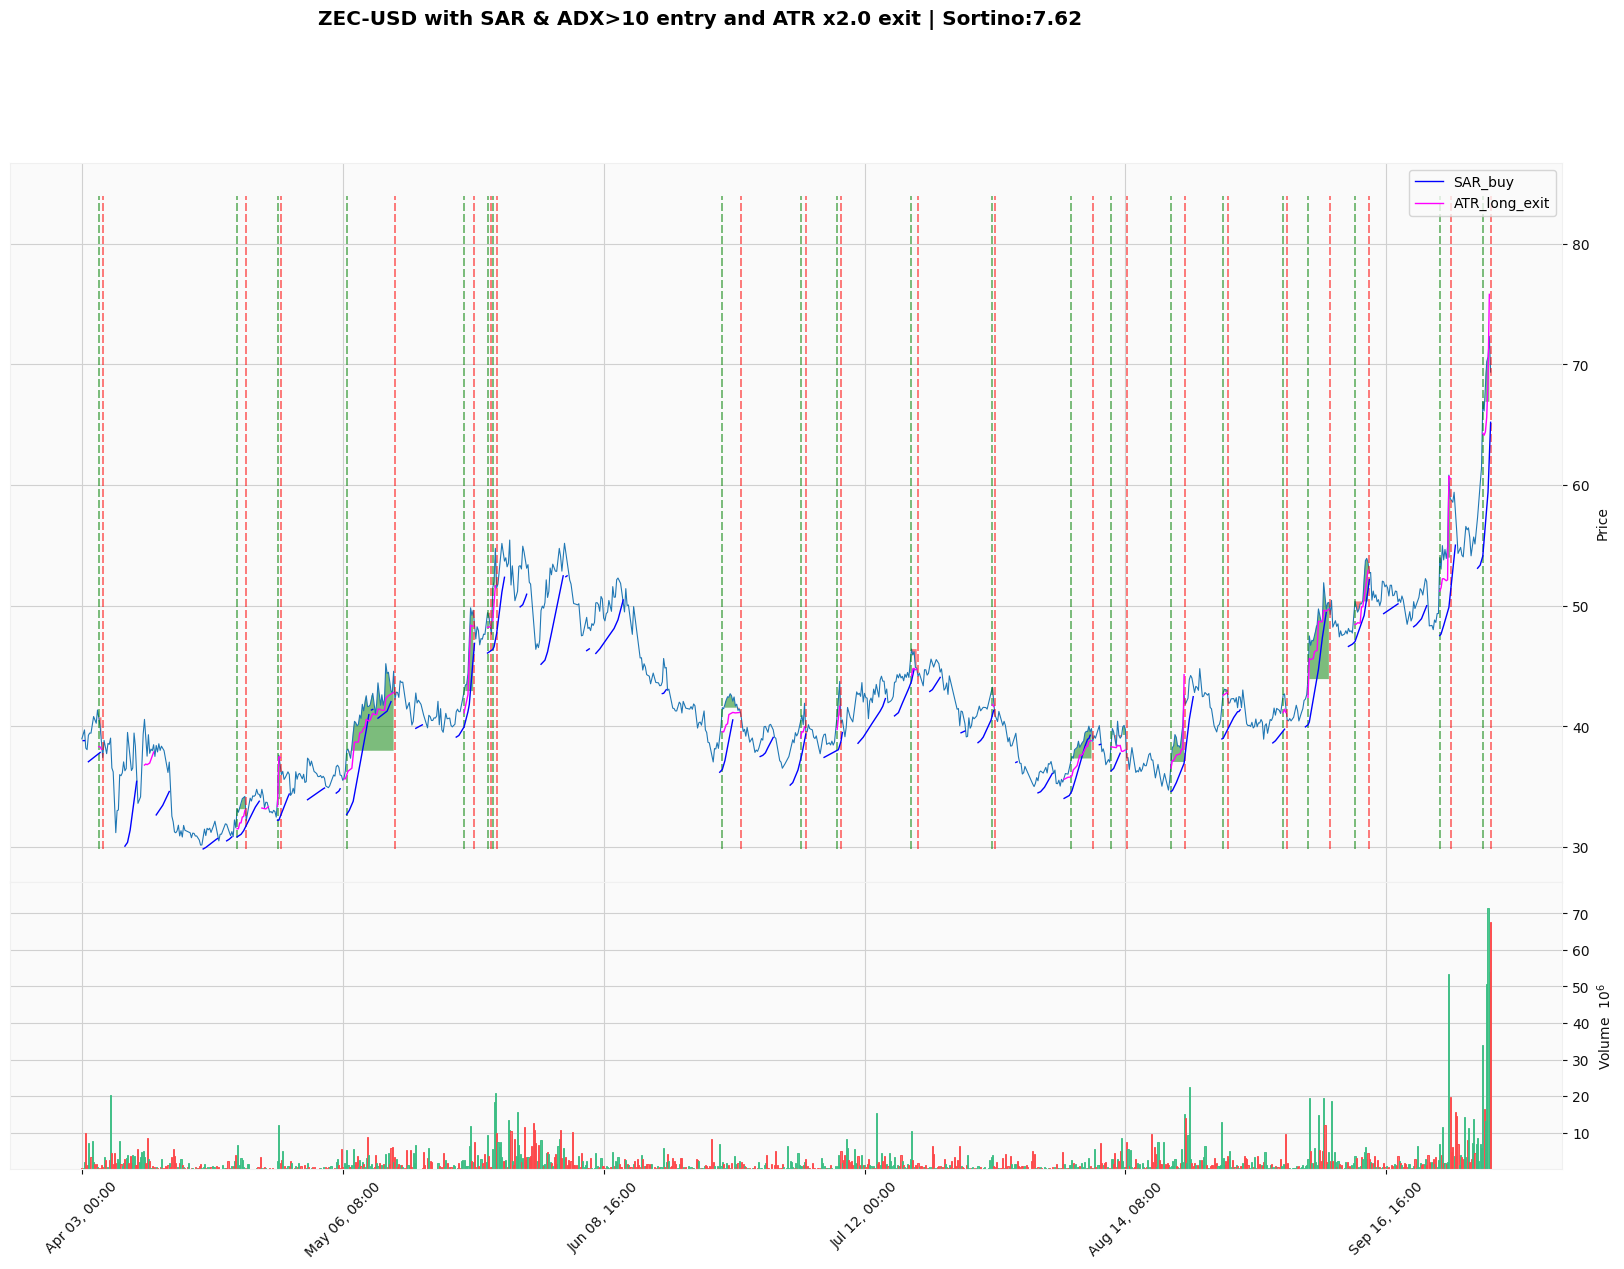

In [149]:
# Combine and color differently
##  Boolean where in position

y1_arr = signals['close'].values
filtered_entry = signals['filtered_entry']
filtered_exit = signals['filtered_exit']
in_position = signals['in_position']

y2 = pd.Series(np.nan, index=filtered_entry.index, dtype="float64")
y2[filtered_entry] = signals['close'][filtered_entry]
y2.ffill(inplace=True)
y2.bfill(inplace=True)
y2_arr = y2.values
in_p = in_position.fillna(False)
in_p_arr = in_p.values
mask_gt = (y1_arr > y2_arr) & in_p_arr
mask_le = (~mask_gt) & in_p_arr
# fill_between = dict(y1=y1_arr, y2=y2_arr, where=in_p_arr, facecolor='green', alpha=0.3)

# 2) Build two fill regions
fill_green = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_gt,
    facecolor='green',
    alpha=0.5
)

fill_red = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_le,
    facecolor='red',
    alpha=0.5
)

# 3) Pass as a list to mplfinance.plot
fill_between = [fill_green, fill_red]
# Build sorted timestamps with colors (keeps colors aligned with dates)
entries = [(ts, 'g') for ts in filtered_entry[filtered_entry].index]
exits = [(ts, 'r') for ts in filtered_exit[filtered_exit].index]
pairs = sorted(entries + exits, key=lambda x: x[0])

# Extract in order expected by mplfinance
vline_dates = [ts for ts, _ in pairs]
vline_colors = [c for _, c in pairs]

adx_line = pd.Series(adx_threshold, index=df.index)
zero_line = pd.Series(0.0, index=df.index)
addplots = [
    mpf.make_addplot(signals['sar'], type='line', color='blue', width=1.0, label='SAR_buy'),
    mpf.make_addplot(signals['ce_l'], type='line', color='magenta', width=1.0, label='ATR_long_exit',
                     secondary_y=False),

]

# keep your existing addplots; no need to append invisible lines
all_addplots = addplots

fig, axlist = mpf.plot(
    df,
    type="line",
    volume=True,
    style="yahoo",
    addplot=all_addplots,
    vlines=dict(
        vlines=vline_dates,
        colors=vline_colors,
        linewidths=1.5,
        alpha=0.5,
        linestyle='dashed',
    ),
    figratio=(18, 12),
    figscale=2.5,
    tight_layout=False,
    title=f"{symbols[0]}-USD with SAR & ADX>{adx_threshold} entry and ATR x{atr_multiplier:.1f} exit | Sortino:{stats['sortino']:.2f}",
    # xlim=[end - pd.Timedelta(days=150), end],
    returnfig=True,
    fill_between=fill_between,

)

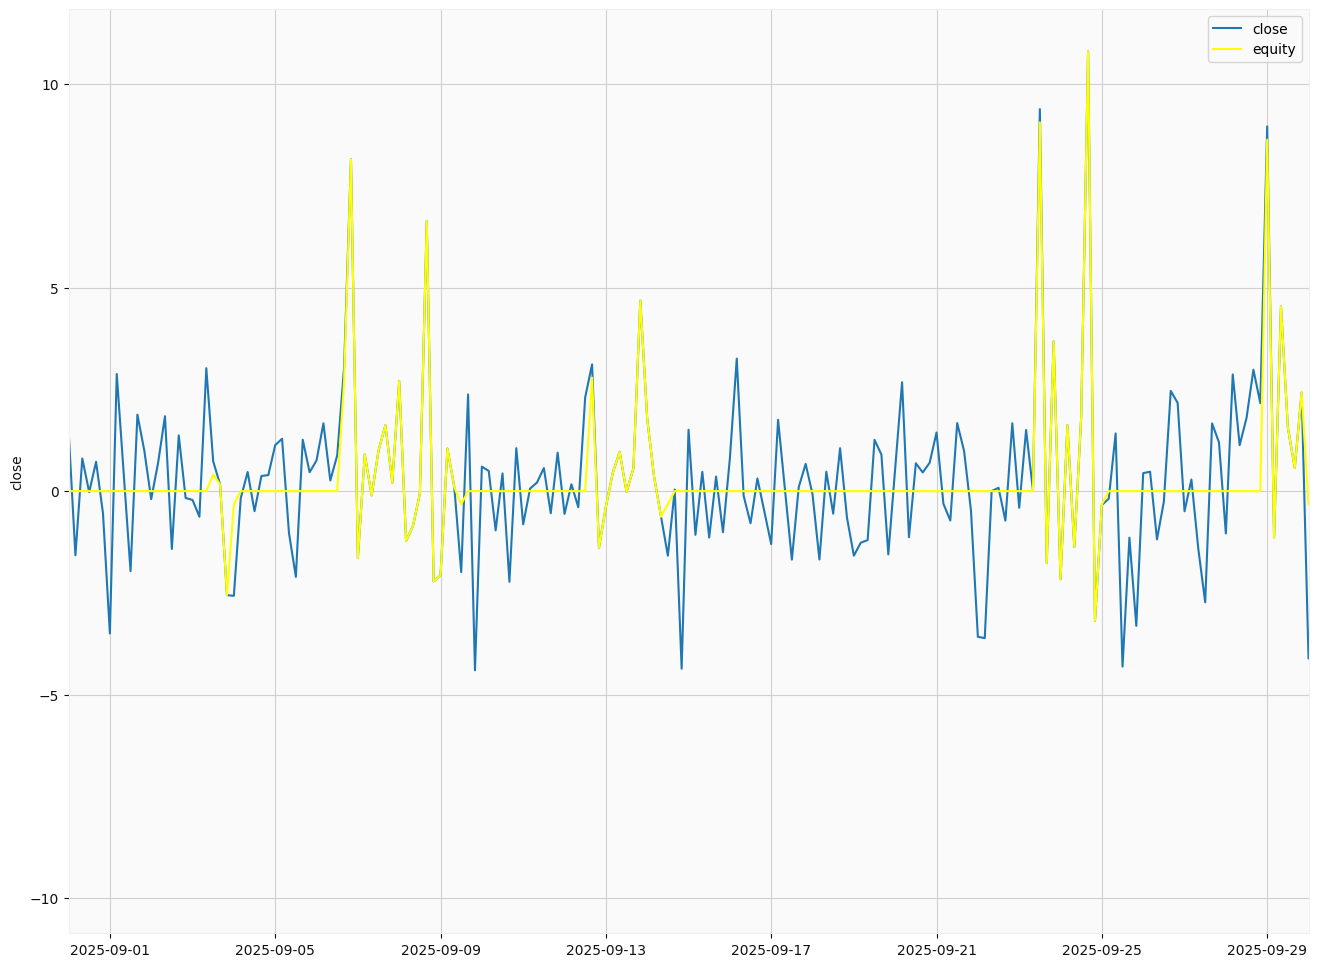

In [159]:
# compare pct change,  is the equity actually moving at the same rate as close??
equity_pct = profit_df['Equity'].pct_change() * 100
close_pct = df['close'].pct_change() * 100

fig = plt.figure(figsize=(16, 12))
sns.lineplot(close_pct, label='close')
sns.lineplot(equity_pct, color='yellow', label='equity')

ax = plt.gca()
ax.set_xlim(end - pd.Timedelta(days=30), end)
plt.legend()
plt.show()

